# 💳 Scoring crédit — EDA & Feature Engineering
## Notebook 1/3

**Auteur :** Diogo Almeida
**Dataset :** [German Credit — OpenML](https://www.openml.org/d/31)

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")
DATA_RAW = Path("..") / "data" / "raw"
DATA_PROCESSED = Path("..") / "data" / "processed"
ASSETS = Path("..") / "assets"
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
ASSETS.mkdir(parents=True, exist_ok=True)

## 1. Chargement

In [2]:
df = pd.read_csv(DATA_RAW / "german_credit.csv")
print(f"Dataset : {len(df)} lignes x {df.shape[1]} colonnes")
print(f"\nColonnes : {df.columns.tolist()}")
display(df.head())

Dataset : 1000 lignes x 21 colonnes

Colonnes : ['checking_status', 'duration', 'credit_history', 'purpose', 'credit_amount', 'savings_status', 'employment', 'installment_commitment', 'personal_status', 'other_parties', 'residence_since', 'property_magnitude', 'age', 'other_payment_plans', 'housing', 'existing_credits', 'job', 'num_dependents', 'own_telephone', 'foreign_worker', 'class']


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,...,real estate,67,none,own,2,skilled,1,yes,yes,good
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,...,real estate,22,none,own,1,skilled,1,none,yes,bad
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,...,real estate,49,none,own,1,unskilled resident,2,none,yes,good
3,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,guarantor,...,life insurance,45,none,for free,1,skilled,2,none,yes,good
4,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,none,...,no known property,53,none,for free,2,skilled,2,none,yes,bad


In [3]:
# Identifier la colonne cible
# OpenML : 'class' avec valeurs 'good'/'bad'
if 'class' in df.columns:
    target_col = 'class'
    df['target'] = (df[target_col] == 'bad').astype(int)  # 1 = defaut
elif 'default' in df.columns:
    target_col = 'default'
    df['target'] = df[target_col].astype(int)
else:
    # Chercher la derniere colonne
    target_col = df.columns[-1]
    df['target'] = df[target_col]

print(f"Colonne cible : {target_col}")
print(f"Distribution :\n{df['target'].value_counts()}")
print(f"Taux de defaut : {df['target'].mean()*100:.1f}%")

Colonne cible : class
Distribution :
target
0    700
1    300
Name: count, dtype: int64
Taux de defaut : 30.0%


## 2. EDA

In [4]:
# Types de variables
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Retirer la cible des features
num_cols = [c for c in num_cols if c != 'target']
cat_cols = [c for c in cat_cols if c != target_col]

print(f"Numeriques ({len(num_cols)}) : {num_cols}")
print(f"Categorielles ({len(cat_cols)}) : {cat_cols}")

Numeriques (7) : ['duration', 'credit_amount', 'installment_commitment', 'residence_since', 'age', 'existing_credits', 'num_dependents']
Categorielles (13) : ['checking_status', 'credit_history', 'purpose', 'savings_status', 'employment', 'personal_status', 'other_parties', 'property_magnitude', 'other_payment_plans', 'housing', 'job', 'own_telephone', 'foreign_worker']


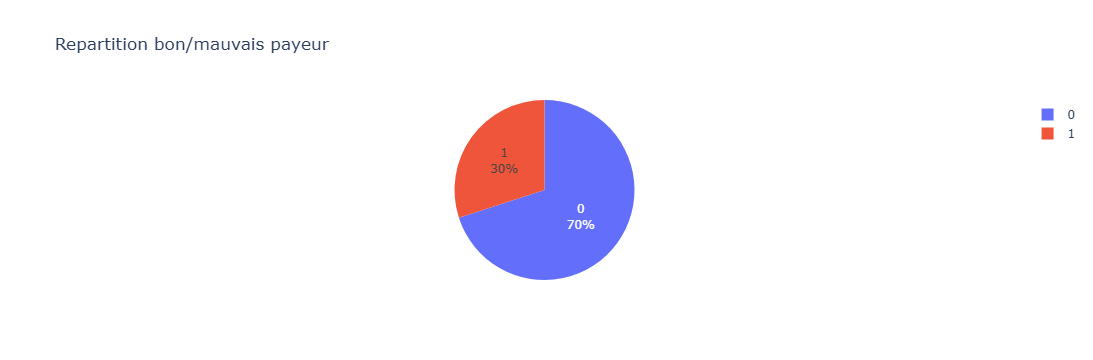

In [5]:
# Distribution de la cible
fig = px.pie(df, names='target', title='Repartition bon/mauvais payeur',
             color_discrete_map={0: '#43A047', 1: '#D64045'},
             template='plotly_white')
fig.update_traces(textinfo='percent+label')
fig.show()

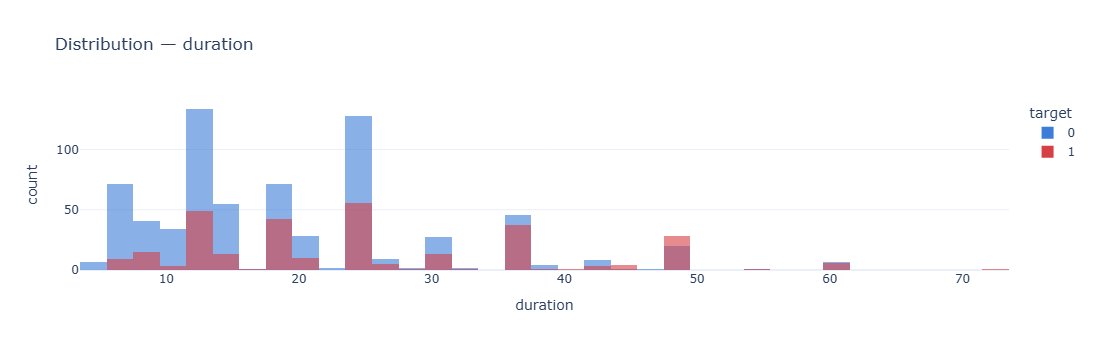

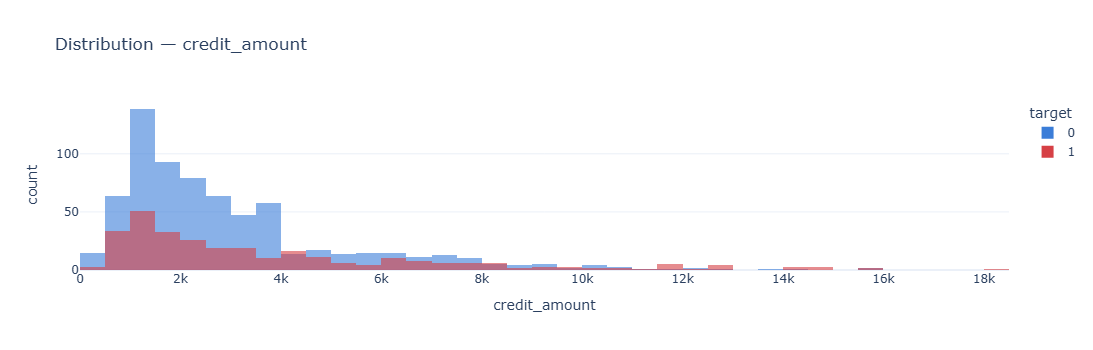

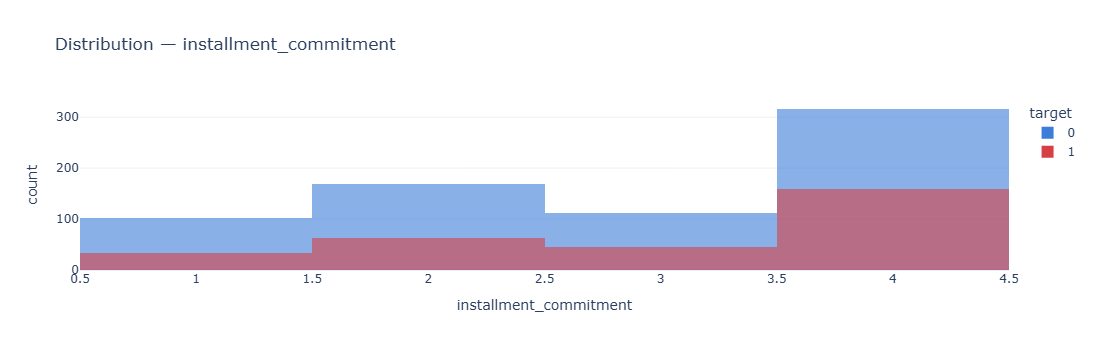

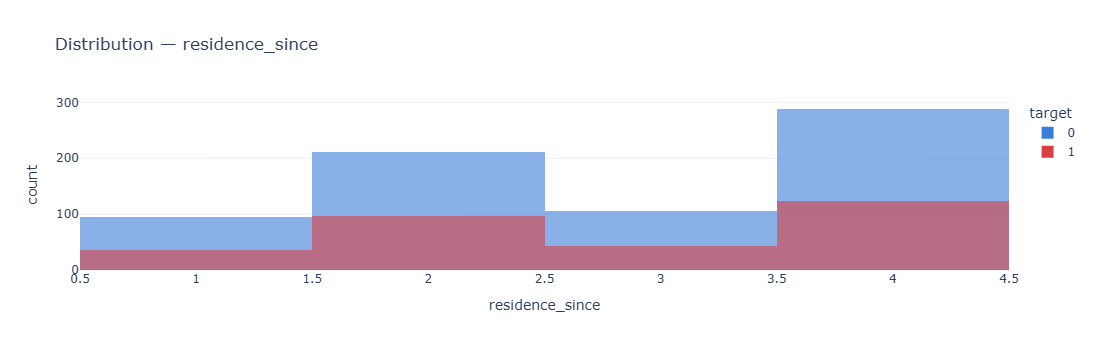

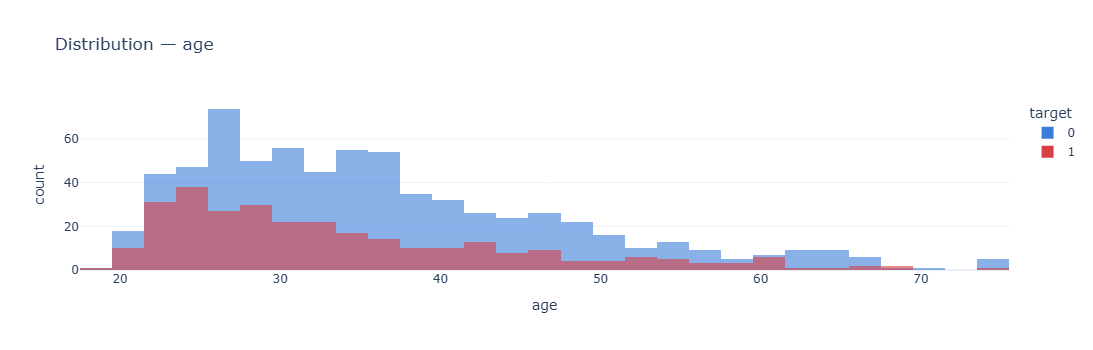

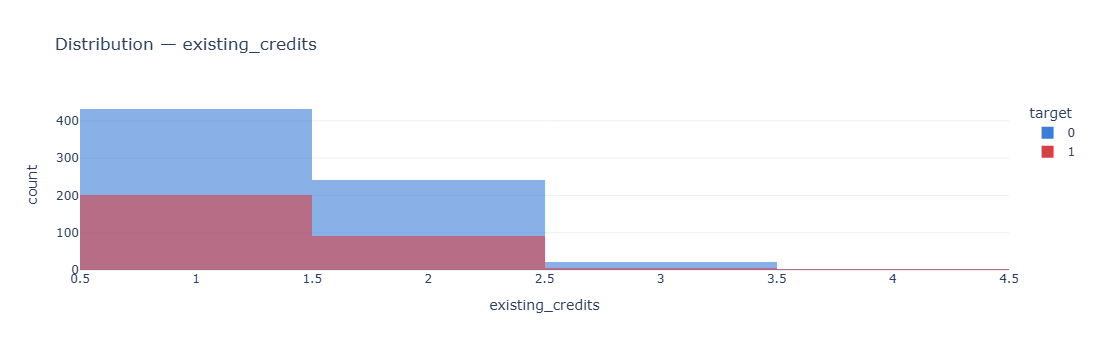

In [6]:
# Distribution des variables numeriques
for col in num_cols[:6]:
    fig = px.histogram(df, x=col, color='target', barmode='overlay',
        title=f'Distribution — {col}',
        color_discrete_map={0: '#3B7DD8', 1: '#D64045'},
        template='plotly_white', opacity=0.6)
    fig.update_layout(height=350)
    fig.show()

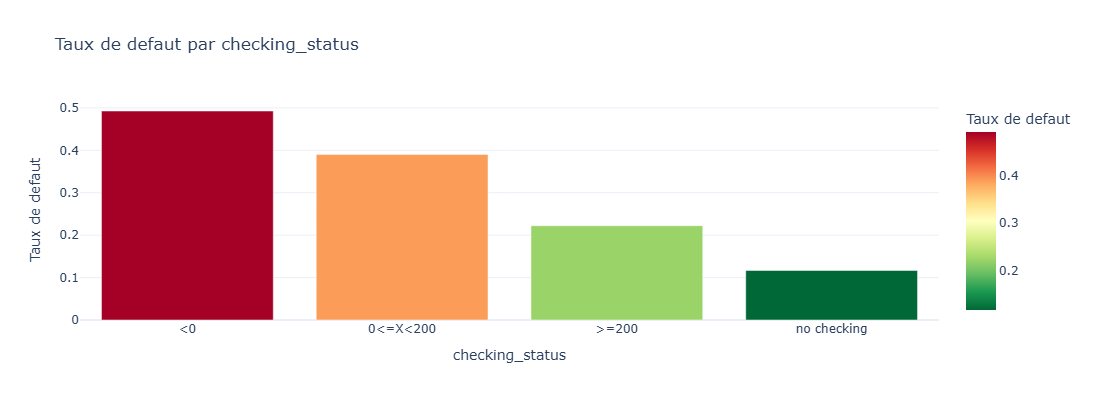

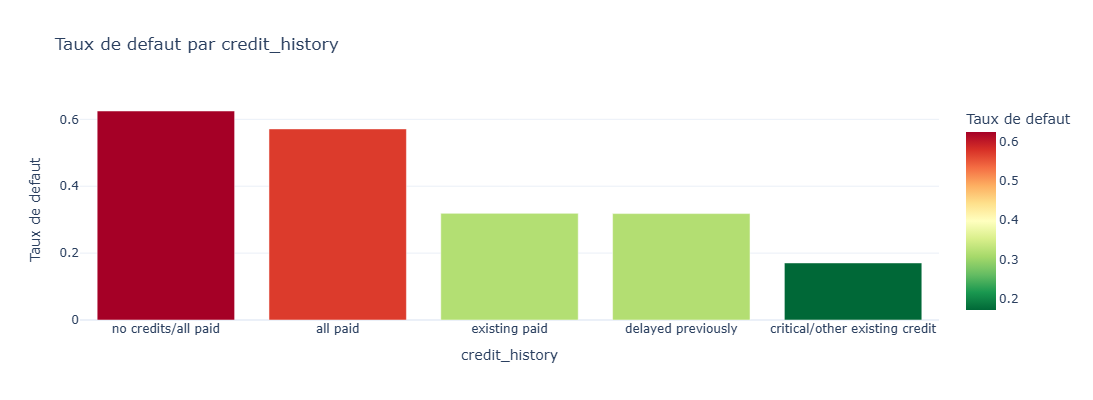

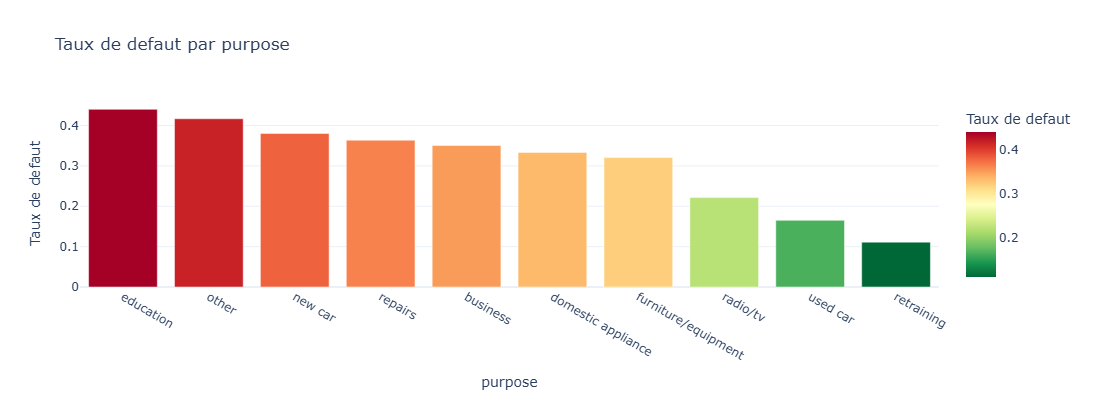

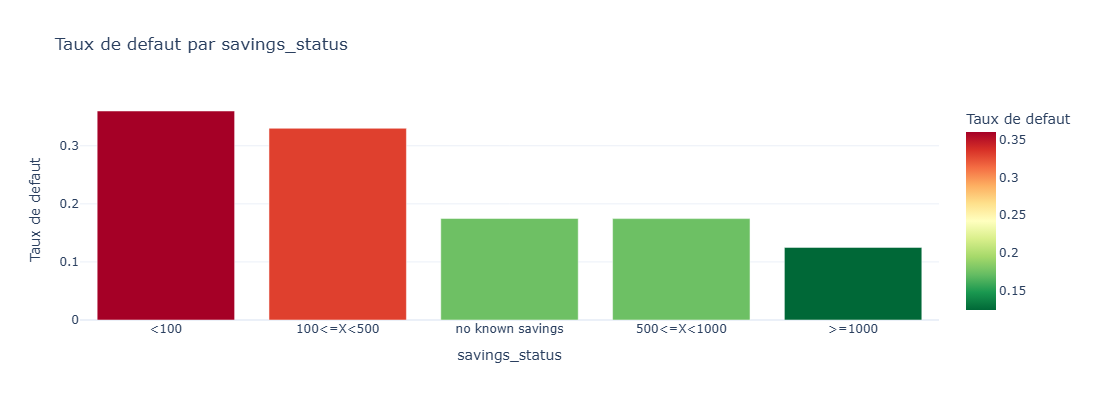

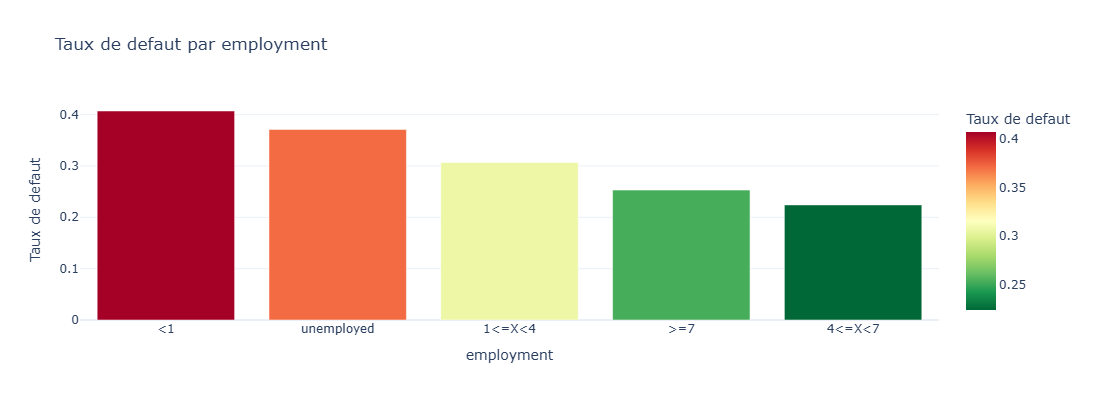

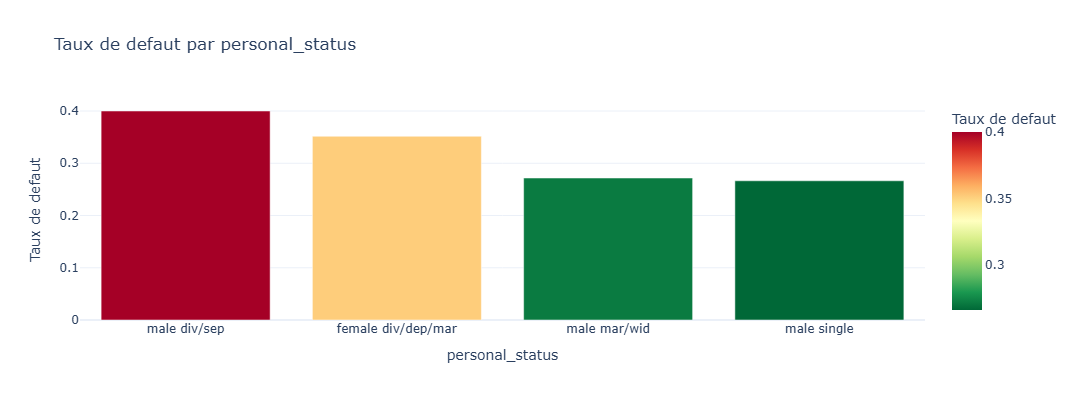

In [7]:
# Taux de defaut par variable categorielle
for col in cat_cols[:6]:
    ct = df.groupby(col)['target'].agg(['mean', 'count']).reset_index()
    ct.columns = [col, 'taux_defaut', 'count']
    ct = ct.sort_values('taux_defaut', ascending=False)
    
    fig = px.bar(ct, x=col, y='taux_defaut',
        title=f'Taux de defaut par {col}',
        labels={'taux_defaut': 'Taux de defaut'},
        color='taux_defaut', color_continuous_scale='RdYlGn_r',
        template='plotly_white')
    fig.update_layout(height=400)
    fig.show()

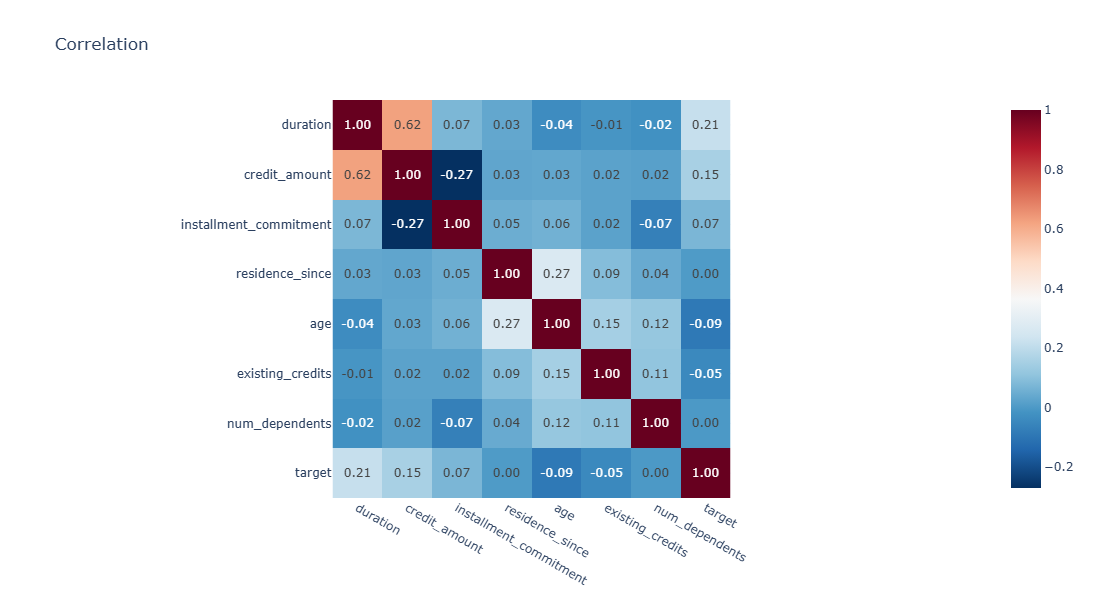

In [8]:
# Matrice de correlation (numeriques)
corr = df[num_cols + ['target']].corr()
fig = px.imshow(corr, text_auto='.2f', title='Correlation',
                color_continuous_scale='RdBu_r', template='plotly_white')
fig.update_layout(height=600, width=700)
fig.show()
fig.write_image(ASSETS / '01_correlation.png', scale=2)

## 3. Feature Engineering

In [9]:
# Extraire le sexe depuis personal_status
if 'personal_status' in df.columns:
    df['is_male'] = df['personal_status'].str.contains('male').astype(int)
    # Attention : 'female' contient aussi 'male' — corriger
    df.loc[df['personal_status'].str.contains('female', na=False), 'is_male'] = 0
    print(f"Sexe : {df['is_male'].value_counts().to_dict()}")

# Tranches d'age
if 'age' in df.columns:
    df['age_group'] = pd.cut(df['age'], bins=[0, 25, 35, 45, 55, 100],
                              labels=['<25', '25-35', '35-45', '45-55', '55+'])
    print(f"Tranches d'age : {df['age_group'].value_counts().to_dict()}")

# Ratio montant / duree
if 'credit_amount' in df.columns and 'duration' in df.columns:
    df['monthly_payment'] = df['credit_amount'] / df['duration']
    df['amount_per_year'] = df['credit_amount'] / (df['duration'] / 12)

print(f"\nFeatures apres engineering : {df.shape[1]} colonnes")

Sexe : {1: 690, 0: 310}
Tranches d'age : {'25-35': 398, '35-45': 226, '<25': 190, '45-55': 115, '55+': 71}

Features apres engineering : 26 colonnes


In [10]:
# Encoder les variables categorielles
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()
label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    label_encoders[col] = le

# Encoder age_group aussi
if 'age_group' in df_encoded.columns:
    le_age = LabelEncoder()
    df_encoded['age_group'] = le_age.fit_transform(df_encoded['age_group'].astype(str))
    label_encoders['age_group'] = le_age

print(f"Dataset encode : {df_encoded.shape}")
display(df_encoded.head())

Dataset encode : (1000, 26)


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,job,num_dependents,own_telephone,foreign_worker,class,target,is_male,age_group,monthly_payment,amount_per_year
0,1,6,1,6,1169,4,3,4,3,2,...,1,1,1,1,good,0,1,3,194.833333,2338.00
1,0,48,3,6,5951,2,0,2,0,2,...,1,1,0,1,bad,1,0,4,123.979167,1487.75
2,3,12,1,2,2096,2,1,2,3,2,...,3,2,0,1,good,0,1,2,174.666667,2096.00
3,1,42,3,3,7882,2,1,2,3,1,...,1,2,0,1,good,0,1,1,187.666667,2252.00
4,1,24,2,4,4870,2,0,3,3,2,...,1,2,0,1,bad,1,1,2,202.916667,2435.00


## 4. Export

In [11]:
# Sauvegarder les deux versions
df.to_csv(DATA_PROCESSED / 'credit_clean.csv', index=False, encoding='utf-8-sig')
df_encoded.to_csv(DATA_PROCESSED / 'credit_encoded.csv', index=False, encoding='utf-8-sig')

import joblib
joblib.dump(label_encoders, DATA_PROCESSED / 'label_encoders.pkl')

print(f'Exporte :')
print(f'  credit_clean.csv ({len(df)} lignes)')
print(f'  credit_encoded.csv ({len(df_encoded)} lignes)')
print(f'  label_encoders.pkl ({len(label_encoders)} encodeurs)')

Exporte :
  credit_clean.csv (1000 lignes)
  credit_encoded.csv (1000 lignes)
  label_encoders.pkl (14 encodeurs)
